In [2]:
pip install pandas numpy matplotlib seaborn plotly


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
import plotly.io as pio

In [4]:
import os
os.listdir()

['.DS_Store', 'retail.ipynb', 'iframe_figures']

In [5]:
df = pd.read_csv('../data/dataset_2017_2020 (2).csv')

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 77750 entries, 0 to 77749
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       77750 non-null  int64  
 1   product_id        77750 non-null  int64  
 2   basket_id         77750 non-null  int64  
 3   loyalty           77750 non-null  str    
 4   household_type    77750 non-null  str    
 5   age_band          77750 non-null  str    
 6   department        77750 non-null  str    
 7   brand             77750 non-null  str    
 8   commodity         77750 non-null  str    
 9   store             77750 non-null  int64  
 10  transaction_date  77750 non-null  str    
 11  price             77750 non-null  float64
 12  days_since_first  77750 non-null  int64  
dtypes: float64(1), int64(5), str(7)
memory usage: 7.7 MB


In [7]:
#part of cleaning
df[['customer_id', 'product_id', 'basket_id', 'store']] = \
df[['customer_id', 'product_id', 'basket_id', 'store']].astype(str)

df['transaction_date'] = pd.to_datetime(df.transaction_date)

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 77750 entries, 0 to 77749
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   customer_id       77750 non-null  str           
 1   product_id        77750 non-null  str           
 2   basket_id         77750 non-null  str           
 3   loyalty           77750 non-null  str           
 4   household_type    77750 non-null  str           
 5   age_band          77750 non-null  str           
 6   department        77750 non-null  str           
 7   brand             77750 non-null  str           
 8   commodity         77750 non-null  str           
 9   store             77750 non-null  str           
 10  transaction_date  77750 non-null  datetime64[us]
 11  price             77750 non-null  float64       
 12  days_since_first  77750 non-null  int64         
dtypes: datetime64[us](1), float64(1), int64(1), str(10)
memory usage: 7.7 MB


In [9]:
#part of cleaning

df = df.drop_duplicates(keep= 'first')

In [10]:
#any nan values? 

df.isna().sum()

customer_id         0
product_id          0
basket_id           0
loyalty             0
household_type      0
age_band            0
department          0
brand               0
commodity           0
store               0
transaction_date    0
price               0
days_since_first    0
dtype: int64

In [11]:
#descriptive analysis
df_decs = df.groupby(['loyalty', 'basket_id']).agg(total_revenue = ('price', sum)).reset_index()
df_decs.groupby(['loyalty']).agg(
    number_of_basket = ('total_revenue', 'count'),
    total_basket_revenue= ('total_revenue','sum'),
    avg_basket_revenue= ('total_revenue', 'mean'),
    median_basket_revenue=('total_revenue', 'median')
)

,number_of_basket,total_basket_revenue,avg_basket_revenue,median_basket_revenue
loyalty,,,,
First Time Buyer,52,3461.14,66.560385,68.855
Loyalist,1413,99956.54,70.740651,68.870
Promiscuous,2033,142281.80,69.986129,68.040


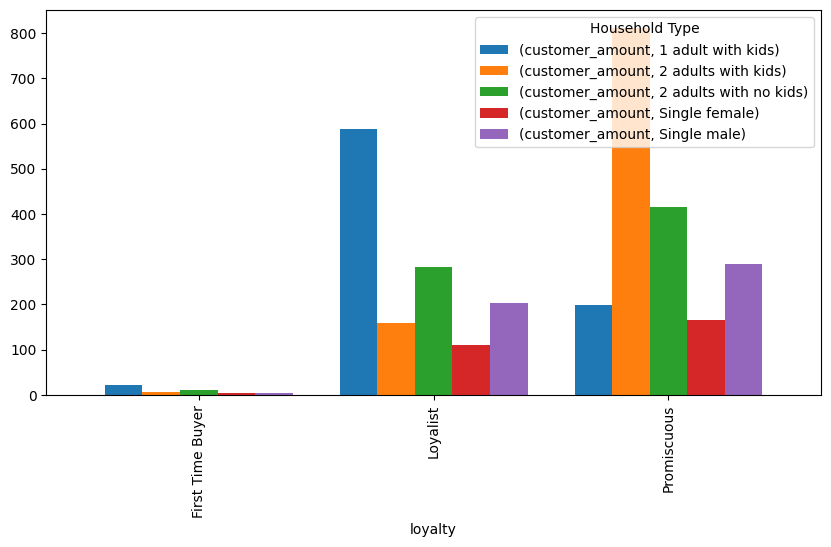

In [12]:
#loyalty types and their households
amount =df.groupby(['loyalty','household_type']).agg(customer_amount = ('customer_id' , pd.Series.nunique))\
.unstack().plot(
    kind='bar',
    figsize=(10,5),
    width=0.8,

)

plt.xlabel = (' ')
plt.ylabel=('Customer Amount')
plt.title =('Customer Count by Loyalty and Household Type')
plt.legend(title='Household Type')
plt.show()

In [13]:
amount =df.groupby(['loyalty','household_type']).agg(customer_amount = ('customer_id' , pd.Series.nunique))
amount_perc = round((amount.customer_amount / amount.customer_amount.sum() * 100), 1)
amount_perc

loyalty           household_type       
First Time Buyer  1 adult with kids         0.7
                  2 adults with kids        0.2
                  2 adults with no kids     0.3
                  Single female             0.1
                  Single male               0.2
Loyalist          1 adult with kids        18.0
                  2 adults with kids        4.9
                  2 adults with no kids     8.6
                  Single female             3.4
                  Single male               6.2
Promiscuous       1 adult with kids         6.1
                  2 adults with kids       24.8
                  2 adults with no kids    12.7
                  Single female             5.0
                  Single male               8.9
Name: customer_amount, dtype: float64

In [14]:
pip install -U nbformat


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [ ]:
#interactive plot of household types and their favourite commodity 
hhd = df.groupby(['household_type', 'commodity']).agg(total_revenue = ('price', 'sum')) \
.sort_values('total_revenue', ascending = False).reset_index()
top_5c = pd.concat(
    [hhd[hhd.household_type == hh] \
     .sort_values('total_revenue', ascending= False).head(5).reset_index()
     for hh in hhd.household_type.unique()])

data = []
for d in top_5c.commodity.unique():
    tmp1 = top_5c[top_5c.commodity == d].groupby(['household_type']).agg(revenue = ('total_revenue', sum)).reset_index()
    data.append(go.Bar(x=tmp1.household_type, y= tmp1.revenue, name= d))
    
go.Figure(
    data = data,
    layout = go.Layout(
        title='Top commodities per household',
        yaxis= dict(
            title= 'Revenue'
        )
    )
).show(Renderer = 'iframe')

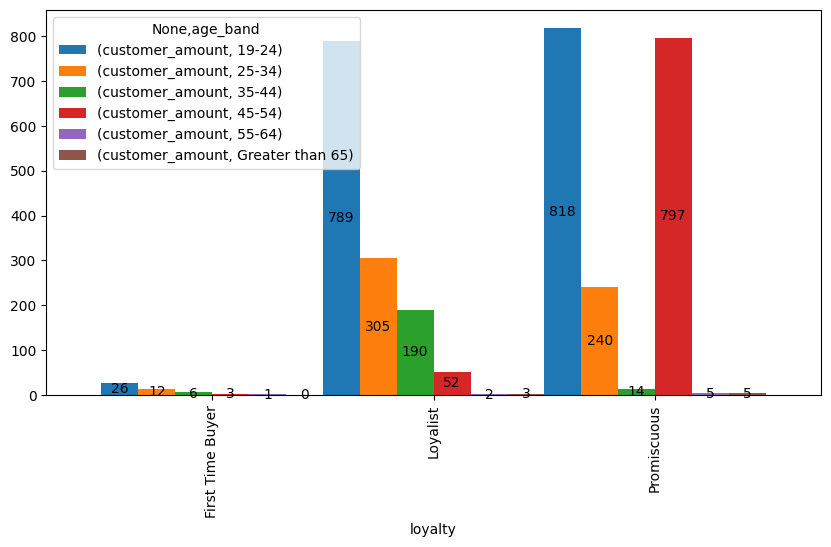

In [16]:
#loyalty types and their age groups 

grouped = df.groupby(['loyalty', 'age_band']).agg(customer_amount = ('customer_id', pd.Series.nunique))\
.unstack()

ax = grouped.plot(
    figsize=(10,5),
    kind= 'bar',
    width=1
)

for container in ax.containers: 
    ax.bar_label(container, label_type = "center")


plt.title=('Customer Count by Loyalty and Age Band')
plt.xlabel=(' ')
plt.ylabel=('Customer Amount')


In [ ]:
#interactive plot of age band and their favourite commodity
abc = df.groupby(['age_band','commodity']).agg(total_revenue=('price', 'sum'))\
.sort_values('total_revenue', ascending = False).reset_index()
tb1 = pd.concat(
    [abc[abc.age_band == ab]
    .sort_values('total_revenue', ascending = False).head(5).reset_index()
    for ab in abc.age_band.unique()])


data = []
for d in tb1.commodity.unique():
    tmp1 = tb1[tb1.commodity == d].groupby(['age_band']).agg(revenue = ('total_revenue', sum)).reset_index()
    data.append(go.Bar(x=tmp1.age_band, y= tmp1.revenue, name= d))
    
go.Figure(
    data = data,
    layout = go.Layout(
        title='Top commodities per age group',
        yaxis= dict(
            title= 'Revenue'
        )
    )
).show(Renderer = 'iframe')



<Axes: xlabel='year,month'>

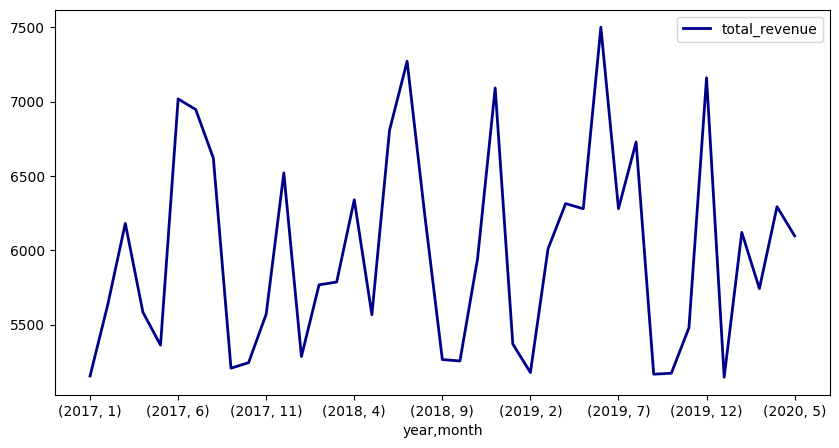

In [19]:
#Revenue over time
df['month']= df.transaction_date.dt.month
df['year']= df.transaction_date.dt.year

df.groupby(['year', 'month']).agg(total_revenue = ('price', 'sum'))\
.plot(
    figsize=(10,5), 
    linewidth = 2, 
    color= 'darkblue'
)

In [20]:
ta = df.groupby(['year', 'month']).agg(total_revenue = ('price', 'sum')).reset_index()

trend_analysis = ta.groupby('year')['total_revenue'].agg(['min', 'max', 'mean'])
trend_analysis



,min,max,mean
year,,,
2017,5154.58,7018.40,5920.134167
2018,5255.45,7271.51,6051.707500
2019,5166.59,7500.64,6053.181667
2020,5146.12,6293.24,5879.840000


In [21]:
#most popular 5 commodity and their seasonal revenue

top_5c = df.groupby('commodity').agg(total_revenue = ('price',sum))\
.sort_values('total_revenue', ascending= False).head(5).reset_index()
top_5c['revenue_percentage'] = round((top_5c['total_revenue'] / top_5c['total_revenue'].sum() * 100) , 0 )
top_5c

,commodity,total_revenue,revenue_percentage
0,Beef,16781.03,41.0
1,Cheese,6280.80,15.0
2,Frozen meat,6152.00,15.0
3,Deli meats,5754.97,14.0
4,Salad,5571.34,14.0


In [ ]:
#interactive plot for top 5 commodities and their revenue over time
df.groupby(['commodity', 'transaction_date']).agg(revenue=('price', sum))\
.sort_values('revenue', ascending = False).reset_index()
data = []

for dd in top_5c.commodity.unique():

    abc = df[df['commodity'] == dd].groupby('transaction_date') \
        .agg(revenue=('price', 'sum')) \
        .reset_index()

    data.append(
        go.Scatter(
            x=abc['transaction_date'],
            y=abc['revenue'],
            name=dd,
            line=dict(dash='solid')
        )
    )

fig = go.Figure(
    data=data,
    layout=go.Layout(
        title='Commodity Trends',
        yaxis=dict(title='Revenue')
    )
)

fig.show(renderer='iframe')

In [23]:
#Departments Revenue Over Time
df['transaction_date'] = pd.to_datetime(df.transaction_date)

rdf =df.groupby(['department', 'transaction_date']).agg(revenue = ('price',sum))\
.sort_values('revenue', ascending= False).reset_index()


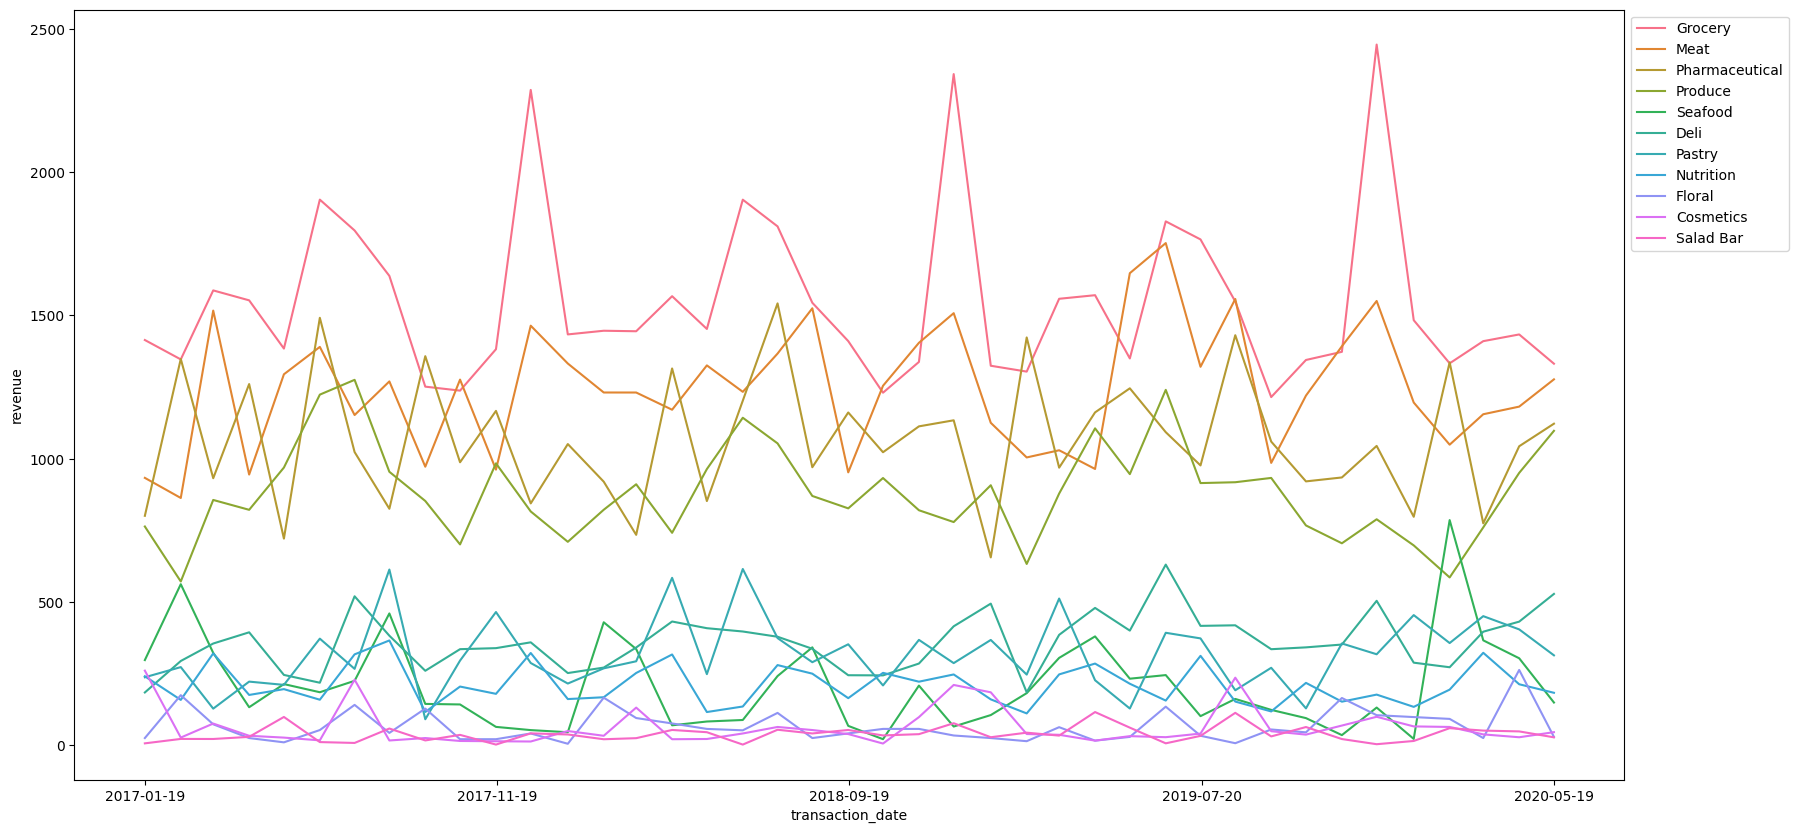

In [24]:
plt.figure(figsize=(20,10))
sns.lineplot(data= rdf, x= 'transaction_date', y = 'revenue', hue= 'department')
plt.title='Departments Revenue over Time'
plt.xlabel="Date" 
plt.ylabel="Revenue"
x_labels= pd.date_range(rdf.transaction_date.min(), rdf.transaction_date.max(), 5)
plt.xticks(x_labels)
plt.legend(bbox_to_anchor=(1, 1), loc='upper left');

In [ ]:
#interactive plot of Departments Revenue over time  
df.groupby(['department', 'transaction_date']).agg(revenue=('price', sum))\
.sort_values('revenue', ascending = False).reset_index()
data = []

for d in df.department.unique(): 
    
    tmp = df[df.department==d].groupby(['transaction_date']).agg(revenue=('price', sum)).reset_index()
    
  
    data.append(go.Scatter(x=tmp.transaction_date, y=tmp.revenue, name = d, line=dict(dash='solid')))
go.Figure(
    data=data,
    layout = go.Layout(
        title ='Department trends',
        yaxis=dict(
            title='Revenue'
        )
    )
).show(renderer = 'iframe')

In [26]:
#popular departments
top_5d = df.groupby('department').agg(total_revenue = ('price', 'sum')) \
.sort_values('total_revenue' , ascending = False)
top_5d['revenue_percentage'] = round((top_5d['total_revenue'] / top_5d['total_revenue'].sum() * 100) , 0 )

top_5d

,total_revenue,revenue_percentage
department,,
Grocery,63334.39,26.0
Meat,50980.70,21.0
Pharmaceutical,43756.58,18.0
Produce,36173.27,15.0
Deli,14714.54,6.0
Pastry,13017.13,5.0
Nutrition,8628.69,4.0
Seafood,8480.99,3.0
Floral,2552.00,1.0
